# 05 - Model Evaluation & Error Analysis

TODO: fill in this notebook.

In [4]:
import sys
from pathlib import Path

sys.path.append('../src')

from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_DIR = Path('..') / 'data' / 'processed' / 'val'

val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
)

print('Class indices:', val_generator.class_indices)
print('Validation images:', val_generator.samples)

Found 320 images belonging to 2 classes.
Class indices: {'Fake Notes': 0, 'Real Notes': 1}
Validation images: 320


In [5]:
from tensorflow.keras.models import load_model
import numpy as np

model = load_model("../models/mobilenetv2_fake_currency.keras")

val_generator.reset()  # make sure we start from the beginning
y_true = val_generator.classes  # actual labels (0=Fake, 1=Real)

y_pred_probs = model.predict(val_generator).ravel()
y_pred = (y_pred_probs > 0.5).astype(int)

print("Predictions complete")
print(f"Total validation samples: {len(y_true)}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step
Predictions complete
Total validation samples: 320


In [6]:
from sklearn.metrics import classification_report

target_names = ["Fake Notes", "Real Notes"]
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

  Fake Notes       0.90      0.95      0.92       130
  Real Notes       0.96      0.93      0.94       190

    accuracy                           0.93       320
   macro avg       0.93      0.94      0.93       320
weighted avg       0.94      0.93      0.93       320



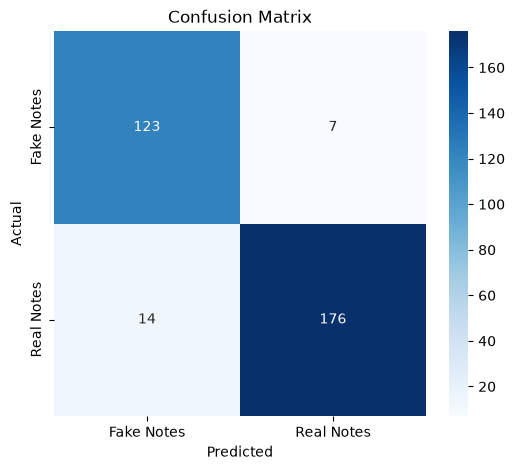

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

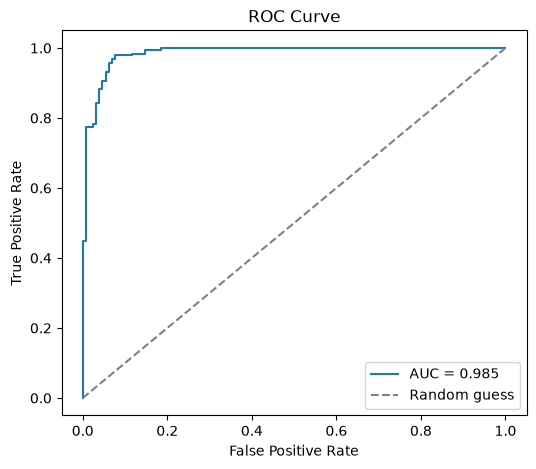

ROC-AUC Score: 0.985


In [9]:
from sklearn.metrics import roc_curve, roc_auc_score

auc_score = roc_auc_score(y_true, y_pred_probs)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"ROC-AUC Score: {auc_score:.3f}")

Total misclassified: 21 out of 320


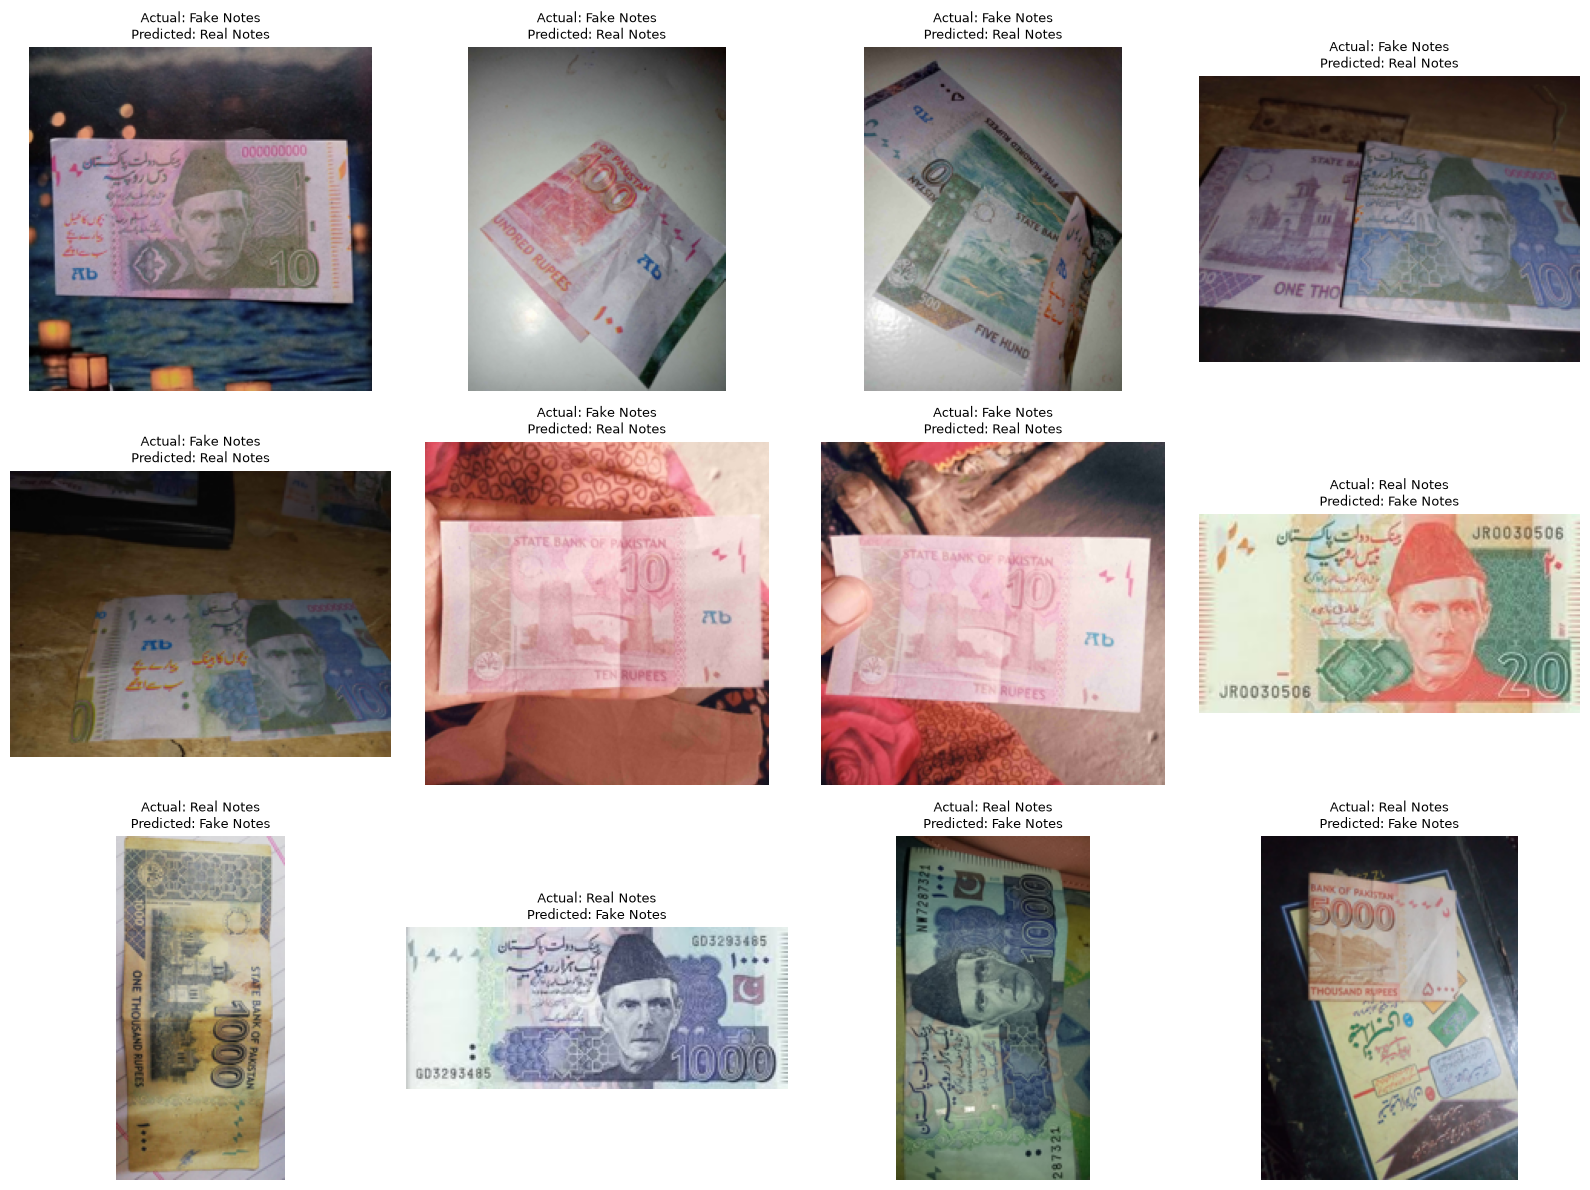

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

misclassified_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_true)}")

filepaths = val_generator.filepaths
shown_idx = misclassified_idx[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for axis, idx in zip(axes.flat, shown_idx):
    with Image.open(filepaths[idx]) as image:
        image = image.convert('RGB')
        image.thumbnail((224, 224))
        preview = np.asarray(image)

    axis.imshow(preview)
    actual = target_names[y_true[idx]]
    predicted = target_names[y_pred[idx]]
    axis.set_title(f"Actual: {actual}\nPredicted: {predicted}", fontsize=9)
    axis.axis("off")

for axis in axes.flat[len(shown_idx):]:
    axis.axis("off")

plt.tight_layout()
plt.show()
plt.close(fig)

## Evaluation Summary

- **Accuracy:** 93.4%
- **ROC-AUC:** 0.985
- **Fake Notes:** Precision 0.90, Recall 0.95, F1 0.92
- **Real Notes:** Precision 0.96, Recall 0.93, F1 0.94
- **Misclassified:** 21 out of 320 (6.6%)
  - 7 fake notes misclassified as real (highest-risk error type)
  - 14 real notes misclassified as fake (false alarms)

### Error Analysis
Manual inspection of misclassified images revealed two patterns:
1. Fake notes misclassified as real were often high-quality counterfeits
   with sharp printing, visually convincing even to a human eye.
2. Real notes misclassified as fake were often worn, faded, or
   photographed in poor lighting — suggesting the model may associate
   texture degradation with counterfeit characteristics.

This indicates model errors correlate with note condition and image
quality rather than being random, which is an important consideration
for real-world deployment.